# 🛒 AFRI-SHOP — Analyse des données e-commerce

## 📊 Présentation

AFRI-SHOP est un projet d'analyse de données portant sur une activité e-commerce en Afrique de l'Ouest.

L'objectif est d'analyser les performances commerciales, d'identifier les principaux moteurs du chiffre d'affaires et de formuler des recommandations permettant d'améliorer la performance de l'entreprise.

### 🎯 Objectifs

- Analyser le chiffre d'affaires et le bénéfice
- Identifier les périodes les plus performantes
- Analyser les méthodes de paiement
- Étudier les statuts des commandes
- Comparer les performances par pays
- Analyser les canaux de vente
- Identifier les catégories et produits performants
- Construire un dashboard synthétique
- Formuler des recommandations business

### 🛠️ Technologies utilisées

- Python
- Pandas
- Matplotlib
- Jupyter Notebook



**Reasoning**:
We will create a clean and centralized library import cell with necessary display settings to avoid repeated imports throughout the notebook, placing it after the initial presentation text cell.



In [854]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration d'affichage de Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ Bibliotheques importees et configurations d'affichage initialisees.")

✅ Bibliotheques importees et configurations d'affichage initialisees.


In [855]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

BASE_PATH = "/content/drive/MyDrive/AFRI_SHOP_DATA_ANALYSIS/data"

In [856]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [857]:
BASE_PATH = "/content/drive/MyDrive/AFRI_SHOP_DATA_ANALYSIS/data"

print(BASE_PATH)

/content/drive/MyDrive/AFRI_SHOP_DATA_ANALYSIS/data


In [858]:
import os

DATA_PATH = "/content/drive/MyDrive/AFRI_SHOP_DATA_ANALYSIS/data"

os.makedirs(DATA_PATH, exist_ok=True)

print("Dossier créé :", DATA_PATH)

Dossier créé : /content/drive/MyDrive/AFRI_SHOP_DATA_ANALYSIS/data


In [859]:
print(os.listdir("/content/drive/MyDrive/AFRI_SHOP_DATA_ANALYSIS"))

['data']


In [860]:
import shutil
import os

files = [
    "customers.csv",
    "products.csv",
    "orders.csv",
    "order_items.csv",
    "payments.csv"
]

for file in files:
    source = f"/content/{file}"
    destination = f"{DATA_PATH}/{file}"

    if os.path.exists(source):
        shutil.copy2(source, destination)
        print(f"✅ {file} copié")
    else:
        print(f"❌ {file} introuvable")

❌ customers.csv introuvable
❌ products.csv introuvable
❌ orders.csv introuvable
❌ order_items.csv introuvable
❌ payments.csv introuvable


In [861]:
customers = pd.read_csv(f"{DATA_PATH}/customers.csv")
products = pd.read_csv(f"{DATA_PATH}/products.csv")
orders = pd.read_csv(f"{DATA_PATH}/orders.csv")
order_items = pd.read_csv(f"{DATA_PATH}/order_items.csv")
payments = pd.read_csv(f"{DATA_PATH}/payments.csv")

print("✅ Les 5 fichiers ont été chargés depuis Google Drive.")

✅ Les 5 fichiers ont été chargés depuis Google Drive.


In [862]:
print("Customers :", customers.shape)
print("Products :", products.shape)
print("Orders :", orders.shape)
print("Order items :", order_items.shape)
print("Payments :", payments.shape)

Customers : (4220, 7)
Products : (30, 6)
Orders : (12500, 7)
Order items : (20576, 11)
Payments : (12500, 7)


In [863]:
# ============================================================
# AUDIT INITIAL DES 5 TABLES
# ============================================================

datasets = {
    "Customers": customers,
    "Products": products,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments
}

for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(f"📊 {name}")
    print("=" * 60)

    print(f"Nombre de lignes    : {df.shape[0]:,}")
    print(f"Nombre de colonnes  : {df.shape[1]}")

    print("\nTypes de données :")
    print(df.dtypes)

    print("\nValeurs manquantes :")
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        print("Aucune valeur manquante ✅")
    else:
        print(missing)

    print("\nDoublons exacts :", df.duplicated().sum())


📊 Customers
Nombre de lignes    : 4,220
Nombre de colonnes  : 7

Types de données :
customer_id    object
first_name     object
last_name      object
country        object
city           object
segment        object
signup_date    object
dtype: object

Valeurs manquantes :
city       18
segment    10
dtype: int64

Doublons exacts : 20

📊 Products
Nombre de lignes    : 30
Nombre de colonnes  : 6

Types de données :
product_id        object
product_name      object
category          object
unit_price_usd     int64
unit_cost_usd      int64
supplier          object
dtype: object

Valeurs manquantes :
Aucune valeur manquante ✅

Doublons exacts : 0

📊 Orders
Nombre de lignes    : 12,500
Nombre de colonnes  : 7

Types de données :
order_id             object
customer_id          object
order_date           object
status               object
sales_channel        object
payment_method       object
shipping_fee_usd    float64
dtype: object

Valeurs manquantes :
Aucune valeur manquante ✅

Doublo

In [864]:
for name, df in datasets.items():
    print(f"{name} :", df.shape)

Customers : (4220, 7)
Products : (30, 6)
Orders : (12500, 7)
Order Items : (20576, 11)
Payments : (12500, 7)


In [865]:
print("=== VALEURS MANQUANTES ===")

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    print(f"\n{name}")

    if missing.empty:
        print("Aucune")
    else:
        print(missing)

=== VALEURS MANQUANTES ===

Customers
city       18
segment    10
dtype: int64

Products
Aucune

Orders
Aucune

Order Items
discount_pct    25
dtype: int64

Payments
Aucune


In [866]:
print("=== DOUBLONS ===")

for name, df in datasets.items():
    print(f"{name} :", df.duplicated().sum())

=== DOUBLONS ===
Customers : 20
Products : 0
Orders : 0
Order Items : 0
Payments : 0


In [867]:

primary_keys = {
    "Customers": ("customer_id", customers),
    "Products": ("product_id", products),
    "Orders": ("order_id", orders),
    "Order Items": ("order_item_id", order_items),
    "Payments": ("payment_id", payments)
}

for name, (key, df) in primary_keys.items():
    duplicates = df[key].duplicated().sum()
    missing = df[key].isna().sum()

    print(f"\n{name}")
    print(f"Clé : {key}")
    print(f"Valeurs manquantes : {missing}")
    print(f"Clés dupliquées : {duplicates}")


Customers
Clé : customer_id
Valeurs manquantes : 0
Clés dupliquées : 20

Products
Clé : product_id
Valeurs manquantes : 0
Clés dupliquées : 0

Orders
Clé : order_id
Valeurs manquantes : 0
Clés dupliquées : 0

Order Items
Clé : order_item_id
Valeurs manquantes : 0
Clés dupliquées : 0

Payments
Clé : payment_id
Valeurs manquantes : 0
Clés dupliquées : 0


In [868]:
# ============================================================
# CONTRÔLE DES CLÉS ÉTRANGÈRES
# ============================================================

unknown_customers = ~orders["customer_id"].isin(customers["customer_id"])
unknown_orders_items = ~order_items["order_id"].isin(orders["order_id"])
unknown_products = ~order_items["product_id"].isin(products["product_id"])
unknown_orders_payments = ~payments["order_id"].isin(orders["order_id"])

print("Commandes avec customer_id inconnu :", unknown_customers.sum())
print("Lignes de commande avec order_id inconnu :", unknown_orders_items.sum())
print("Lignes de commande avec product_id inconnu :", unknown_products.sum())
print("Paiements avec order_id inconnu :", unknown_orders_payments.sum())

Commandes avec customer_id inconnu : 0
Lignes de commande avec order_id inconnu : 0
Lignes de commande avec product_id inconnu : 0
Paiements avec order_id inconnu : 0


In [869]:
# Clients dont la ville est manquante
customers[customers["city"].isna()][
    ["customer_id", "country", "segment"]
]

,customer_id,country,segment
117,C00118,Sénégal,Particulier
458,C00459,Bénin,PME
487,C00488,Nigeria,PME
699,C00700,Ghana,PME
722,C00723,Togo,PME
1092,C01093,Côte d'Ivoire,Particulier
1112,C01113,Sénégal,Particulier
1844,C01845,Togo,Particulier
1902,C01903,Ghana,Particulier
1939,C01940,Nigeria,Entreprise


In [870]:
# Nombre de commandes effectuées par ces clients
missing_city_customers = customers.loc[
    customers["city"].isna(), "customer_id"
]

orders[orders["customer_id"].isin(missing_city_customers)].shape

(58, 7)

In [871]:
customers[customers["segment"].isna()][
    ["customer_id", "country", "city"]
]

,customer_id,country,city
791,C00792,Ghana,Tamale
1071,C01072,Ghana,Accra
1175,C01176,Côte d'Ivoire,Yamoussoukro
1246,C01247,Côte d'Ivoire,Abidjan
1950,C01951,Bénin,Abomey-Calavi
2172,C02173,Sénégal,Saint-Louis
2315,C02316,Sénégal,Touba
3050,C03051,Côte d'Ivoire,San-Pédro
3175,C03176,Bénin,Parakou
4068,C04069,Togo,Kara


In [872]:
order_items["discount_recalculated"] = (
    1 -
    order_items["line_revenue_usd"] /
    (order_items["quantity"] * order_items["unit_price_usd"])
)

In [873]:
order_items.loc[
    order_items["discount_pct"].isna(),
    [
        "order_item_id",
        "quantity",
        "unit_price_usd",
        "line_revenue_usd",
        "discount_recalculated"
    ]
]

,order_item_id,quantity,unit_price_usd,line_revenue_usd,discount_recalculated
1004,OI0001005,3,12,36.00,0.00
1428,OI0001429,4,22,88.00,0.00
2166,OI0002167,4,92,368.00,0.00
2250,OI0002251,1,58,58.00,0.00
2416,OI0002417,1,18,18.00,0.00
3111,OI0003112,1,39,39.00,0.00
6150,OI0006151,2,12,24.00,0.00
7088,OI0007089,2,18,36.00,0.00
7521,OI0007522,3,12,36.00,0.00
8074,OI0008075,4,245,882.00,0.10


In [874]:
order_items["discount_pct"] = order_items["discount_pct"].fillna(
    order_items["discount_recalculated"]
)

In [875]:
print(
    "Valeurs manquantes après traitement :",
    order_items["discount_pct"].isna().sum()
)

Valeurs manquantes après traitement : 0


In [876]:
order_items.loc[
    order_items["discount_pct"].isna(),
    [
        "order_item_id",
        "quantity",
        "unit_price_usd",
        "line_revenue_usd",
        "discount_recalculated"
    ]
]

,order_item_id,quantity,unit_price_usd,line_revenue_usd,discount_recalculated


In [877]:
negative_shipping = orders[orders["shipping_fee_usd"] < 0]

print("Nombre de frais d'expédition négatifs :", len(negative_shipping))

negative_shipping[
    ["order_id", "order_date", "shipping_fee_usd"]
]

Nombre de frais d'expédition négatifs : 12


,order_id,order_date,shipping_fee_usd
320,O000321,2025-12-18,-5.0
789,O000790,2026-02-04,-5.0
1684,O001685,2025-09-27,-5.0
2958,O002959,2025-09-21,-5.0
5113,O005114,2026-06-06,-5.0
5392,O005393,2026-04-18,-5.0
5578,O005579,2026-02-28,-5.0
9563,O009564,2025-12-27,-5.0
9619,O009620,2026-05-21,-5.0
10156,O010157,2025-10-05,-5.0


In [878]:
invalid_quantity = order_items[order_items["quantity"] <= 0]

print("Quantités invalides :", len(invalid_quantity))

invalid_quantity[
    ["order_item_id", "order_id", "product_id", "quantity"]
]

Quantités invalides : 0


,order_item_id,order_id,product_id,quantity


In [879]:
invalid_prices = order_items[
    (order_items["unit_price_usd"] <= 0) |
    (order_items["unit_cost_usd"] < 0)
]

print("Prix/coûts invalides :", len(invalid_prices))

invalid_prices[
    [
        "order_item_id",
        "product_id",
        "unit_price_usd",
        "unit_cost_usd"
    ]
]

Prix/coûts invalides : 0


,order_item_id,product_id,unit_price_usd,unit_cost_usd


In [880]:
order_items["revenue_recalculated"] = (
    order_items["quantity"]
    * order_items["unit_price_usd"]
    * (1 - order_items["discount_pct"])
)

order_items["revenue_difference"] = (
    order_items["line_revenue_usd"]
    - order_items["revenue_recalculated"]
).round(2)

print(
    "Lignes avec incohérence de revenu :",
    (order_items["revenue_difference"].abs() > 0.01).sum()
)

Lignes avec incohérence de revenu : 0


In [881]:
negative_shipping = orders[orders["shipping_fee_usd"] < 0].copy()

print("Nombre de commandes concernées :", len(negative_shipping))

negative_shipping[
    [
        "order_id",
        "order_date",
        "status",
        "sales_channel",
        "payment_method",
        "shipping_fee_usd"
    ]
]

Nombre de commandes concernées : 12


,order_id,order_date,status,sales_channel,payment_method,shipping_fee_usd
320,O000321,2025-12-18,Completed,Site web,Carte bancaire,-5.0
789,O000790,2026-02-04,Pending,WhatsApp,Virement,-5.0
1684,O001685,2025-09-27,Completed,WhatsApp,Carte bancaire,-5.0
2958,O002959,2025-09-21,Returned,Site web,Carte bancaire,-5.0
5113,O005114,2026-06-06,Completed,Site web,Mobile Money,-5.0
5392,O005393,2026-04-18,Completed,Site web,Mobile Money,-5.0
5578,O005579,2026-02-28,Completed,Marketplace,Mobile Money,-5.0
9563,O009564,2025-12-27,Completed,WhatsApp,Mobile Money,-5.0
9619,O009620,2026-05-21,Completed,Marketplace,Mobile Money,-5.0
10156,O010157,2025-10-05,Completed,WhatsApp,Mobile Money,-5.0


In [882]:
print(
    "Montant total des frais négatifs :",
    negative_shipping["shipping_fee_usd"].sum()
)

print(
    "Frais minimum :",
    negative_shipping["shipping_fee_usd"].min()
)

print(
    "Frais maximum :",
    negative_shipping["shipping_fee_usd"].max()
)

Montant total des frais négatifs : -60.0
Frais minimum : -5.0
Frais maximum : -5.0


In [883]:
print("Quantités <= 0 :", (order_items["quantity"] <= 0).sum())

print(
    "Prix de vente <= 0 :",
    (order_items["unit_price_usd"] <= 0).sum()
)

print(
    "Coûts < 0 :",
    (order_items["unit_cost_usd"] < 0).sum()
)

Quantités <= 0 : 0
Prix de vente <= 0 : 0
Coûts < 0 : 0


In [884]:
print(
    "Incohérences de revenu :",
    (order_items["revenue_difference"].abs() > 0.01).sum()
)

Incohérences de revenu : 0


In [885]:
orders_clean = orders.copy()

negative_shipping = orders_clean["shipping_fee_usd"] < 0

print("Anomalies détectées :", negative_shipping.sum())

Anomalies détectées : 12


In [886]:
orders_clean.loc[negative_shipping, "shipping_fee_usd"] = np.nan

print(
    "Frais d'expédition négatifs après correction :",
    (orders_clean["shipping_fee_usd"] < 0).sum()
)

print(
    "Frais d'expédition maintenant manquants :",
    orders_clean["shipping_fee_usd"].isna().sum()
)

Frais d'expédition négatifs après correction : 0
Frais d'expédition maintenant manquants : 12


In [887]:
customers_clean = customers.copy()
products_clean = products.copy()
orders_clean = orders.copy()
order_items_clean = order_items.copy()
payments_clean = payments.copy()

In [888]:
clean_datasets = {
    "Customers": customers_clean,
    "Products": products_clean,
    "Orders": orders_clean,
    "Order Items": order_items_clean,
    "Payments": payments_clean
}

print("========== CONTRÔLE FINAL ==========")

for name, df in clean_datasets.items():
    print(f"\n{name}")
    print(f"Lignes : {df.shape[0]:,}")
    print(f"Colonnes : {df.shape[1]}")
    print(f"Doublons exacts : {df.duplicated().sum()}")
    print(f"Valeurs manquantes : {df.isna().sum().sum()}")

========== CONTRÔLE FINAL ==========

Customers
Lignes : 4,220
Colonnes : 7
Doublons exacts : 20
Valeurs manquantes : 28

Products
Lignes : 30
Colonnes : 6
Doublons exacts : 0
Valeurs manquantes : 0

Orders
Lignes : 12,500
Colonnes : 7
Doublons exacts : 0
Valeurs manquantes : 0

Order Items
Lignes : 20,576
Colonnes : 14
Doublons exacts : 0
Valeurs manquantes : 0

Payments
Lignes : 12,500
Colonnes : 7
Doublons exacts : 0
Valeurs manquantes : 0


In [889]:
print("========== INTÉGRITÉ RÉFÉRENTIELLE ==========")

print(
    "Orders → Customers :",
    (~orders_clean["customer_id"].isin(customers_clean["customer_id"])).sum()
)

print(
    "Order Items → Orders :",
    (~order_items_clean["order_id"].isin(orders_clean["order_id"])).sum()
)

print(
    "Order Items → Products :",
    (~order_items_clean["product_id"].isin(products_clean["product_id"])).sum()
)

print(
    "Payments → Orders :",
    (~payments_clean["order_id"].isin(orders_clean["order_id"])).sum()
)

========== INTÉGRITÉ RÉFÉRENTIELLE ==========
Orders → Customers : 0
Order Items → Orders : 0
Order Items → Products : 0
Payments → Orders : 0


In [890]:
# ============================================================
# 1. AJOUT DES INFORMATIONS PRODUITS
# ============================================================

df_analysis = order_items_clean.merge(
    products_clean[
        [
            "product_id",
            "product_name",
            "category",
            "supplier"
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("Dimensions après jointure produits :", df_analysis.shape)

Dimensions après jointure produits : (20576, 17)


In [891]:
# ============================================================
# 2. AJOUT DES INFORMATIONS COMMANDES
# ============================================================

df_analysis = df_analysis.merge(
    orders_clean[
        [
            "order_id",
            "customer_id",
            "order_date",
            "status",
            "sales_channel",
            "payment_method",
            "shipping_fee_usd"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

print("Dimensions après jointure commandes :", df_analysis.shape)

Dimensions après jointure commandes : (20576, 23)


In [892]:
# Vérifier les customer_id en double
duplicates_customers = customers_clean[
    customers_clean["customer_id"].duplicated(keep=False)
].sort_values("customer_id")

print("Nombre de lignes concernées :", len(duplicates_customers))
print("Nombre de customer_id concernés :",
      duplicates_customers["customer_id"].nunique())

duplicates_customers.head(20)

Nombre de lignes concernées : 40
Nombre de customer_id concernés : 20


,customer_id,first_name,last_name,country,city,segment,signup_date
298,C00299,Koffi,Diop,Côte d'Ivoire,Yamoussoukro,Particulier,2024-06-03
4204,C00299,Koffi,Diop,Côte d'Ivoire,Yamoussoukro,Particulier,2024-06-03
351,C00352,Malick,Amoussou,Ghana,Accra,Entreprise,2025-03-17
4207,C00352,Malick,Amoussou,Ghana,Accra,Entreprise,2025-03-17
497,C00498,Ruth,Gomis,Bénin,Parakou,Particulier,2026-01-25
4217,C00498,Ruth,Gomis,Bénin,Parakou,Particulier,2026-01-25
4219,C00735,Grâce,Ahouansou,Nigeria,Abuja,PME,2026-03-01
734,C00735,Grâce,Ahouansou,Nigeria,Abuja,PME,2026-03-01
1029,C01030,Ruth,Amani,Bénin,Cotonou,Particulier,2025-03-05
4210,C01030,Ruth,Amani,Bénin,Cotonou,Particulier,2025-03-05


In [893]:
# Vérifier si les doublons sont exactement identiques
print(
    "Doublons parfaitement identiques :",
    duplicates_customers.duplicated().sum()
)

Doublons parfaitement identiques : 20


In [894]:
customers_clean = customers_clean.drop_duplicates(
    subset="customer_id",
    keep="first"
).copy()

print("Nombre de clients après nettoyage :", len(customers_clean))
print(
    "Customer_id encore dupliqués :",
    customers_clean["customer_id"].duplicated().sum()
)

Nombre de clients après nettoyage : 4200
Customer_id encore dupliqués : 0


In [895]:
# ============================================================
# RECONSTRUCTION DE LA TABLE ANALYTIQUE
# ============================================================

df_analysis = order_items_clean.copy()

# 1. Produits
df_analysis = df_analysis.merge(
    products_clean[
        [
            "product_id",
            "product_name",
            "category",
            "supplier"
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

# 2. Commandes
df_analysis = df_analysis.merge(
    orders_clean[
        [
            "order_id",
            "customer_id",
            "order_date",
            "status",
            "sales_channel",
            "payment_method",
            "shipping_fee_usd"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

# 3. Clients
df_analysis = df_analysis.merge(
    customers_clean[
        [
            "customer_id",
            "first_name",
            "last_name",
            "country",
            "city",
            "segment",
            "signup_date"
        ]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

print("========== TABLE ANALYTIQUE ==========")
print("Lignes :", f"{df_analysis.shape[0]:,}")
print("Colonnes :", df_analysis.shape[1])

========== TABLE ANALYTIQUE ==========
Lignes : 20,576
Colonnes : 29


In [896]:
print("\n========== CONTRÔLES ==========")

print(
    "Doublons order_item_id :",
    df_analysis["order_item_id"].duplicated().sum()
)

print(
    "Product_id inconnus :",
    df_analysis["product_id"].isna().sum()
)

print(
    "Order_id inconnus :",
    df_analysis["order_id"].isna().sum()
)

print(
    "Customer_id inconnus :",
    df_analysis["customer_id"].isna().sum()
)


========== CONTRÔLES ==========
Doublons order_item_id : 0
Product_id inconnus : 0
Order_id inconnus : 0
Customer_id inconnus : 0


In [897]:
# ============================================================
# 1. CRÉATION DES KPI FINANCIERS
# ============================================================

# Chiffre d'affaires
df_analysis["revenue"] = df_analysis["line_revenue_usd"]

# Coût
df_analysis["cost"] = df_analysis["line_cost_usd"]

# Bénéfice
df_analysis["profit"] = df_analysis["line_profit_usd"]

# Marge en %
df_analysis["margin_pct"] = (
    df_analysis["profit"] / df_analysis["revenue"] * 100
)

# Vérification
df_analysis[
    [
        "order_item_id",
        "revenue",
        "cost",
        "profit",
        "margin_pct"
    ]
].head(10)

,order_item_id,revenue,cost,profit,margin_pct
0,OI0000001,190.00,139,51.00,26.842105
1,OI0000002,38.00,21,17.00,44.736842
2,OI0000003,15.30,10,5.30,34.640523
3,OI0000004,36.00,20,16.00,44.444444
4,OI0000005,380.00,278,102.00,26.842105
5,OI0000006,114.00,63,51.00,44.736842
6,OI0000007,91.20,56,35.20,38.596491
7,OI0000008,57.80,38,19.80,34.256055
8,OI0000009,38.00,21,17.00,44.736842
9,OI0000010,37.05,23,14.05,37.921727


In [898]:
# ============================================================
# 2. KPI GLOBAUX
# ============================================================

total_revenue = df_analysis["revenue"].sum()
total_cost = df_analysis["cost"].sum()
total_profit = df_analysis["profit"].sum()

overall_margin = (
    total_profit / total_revenue * 100
)

total_orders = df_analysis["order_id"].nunique()
total_customers = df_analysis["customer_id"].nunique()

average_order_value = (
    total_revenue / total_orders
)

print("========== KPI GLOBAUX ==========")
print(f"Chiffre d'affaires : ${total_revenue:,.2f}")
print(f"Coût total         : ${total_cost:,.2f}")
print(f"Bénéfice total     : ${total_profit:,.2f}")
print(f"Taux de marge      : {overall_margin:.2f}%")
print(f"Nombre de commandes: {total_orders:,}")
print(f"Nombre de clients  : {total_customers:,}")
print(f"Panier moyen       : ${average_order_value:,.2f}")

========== KPI GLOBAUX ==========
Chiffre d'affaires : $4,644,402.15
Coût total         : $3,392,093.00
Bénéfice total     : $1,252,309.15
Taux de marge      : 26.96%
Nombre de commandes: 12,500
Nombre de clients  : 3,991
Panier moyen       : $371.55


In [899]:
# ============================================================
# 3. CONTRÔLES FINANCIERS
# ============================================================

print("========== CONTRÔLES ==========")

print(
    "CA calculé depuis les lignes :",
    round(df_analysis["line_revenue_usd"].sum(), 2)
)

print(
    "CA calculé avec revenue :",
    round(df_analysis["revenue"].sum(), 2)
)

print(
    "Bénéfice calculé depuis les lignes :",
    round(df_analysis["line_profit_usd"].sum(), 2)
)

print(
    "Bénéfice calculé avec profit :",
    round(df_analysis["profit"].sum(), 2)
)

========== CONTRÔLES ==========
CA calculé depuis les lignes : 4644402.15
CA calculé avec revenue : 4644402.15
Bénéfice calculé depuis les lignes : 1252309.15
Bénéfice calculé avec profit : 1252309.15


In [900]:
# Vérification des marges
print("Marge minimale :", round(df_analysis["margin_pct"].min(), 2), "%")
print("Marge maximale :", round(df_analysis["margin_pct"].max(), 2), "%")
print("Marge moyenne  :", round(df_analysis["margin_pct"].mean(), 2), "%")

Marge minimale : 8.79 %
Marge maximale : 50.0 %
Marge moyenne  : 35.9 %


In [901]:
# ============================================================
# ANALYSE 1 — PERFORMANCE DES PRODUITS
# ============================================================

product_analysis = (
    df_analysis
    .groupby(["product_id", "product_name", "category"], as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum"),
        quantity_sold=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
)

# Calcul du taux de marge
product_analysis["margin_pct"] = (
    product_analysis["profit"]
    / product_analysis["revenue"]
    * 100
)

# Trier par chiffre d'affaires
product_analysis = product_analysis.sort_values(
    "revenue",
    ascending=False
)

product_analysis.head(10)

,product_id,product_name,category,revenue,cost,profit,quantity_sold,orders,margin_pct
1,P0002,Ordinateur portable HP 15,Ordinateurs,475305.90,373100,102205.90,820,392,21.503184
0,P0001,Ordinateur portable Lenovo IdeaPad,Ordinateurs,431886.00,338910,92976.00,869,431,21.527903
26,P0027,Smartphone Xiaomi Redmi,Smartphones,379196.30,290510,88686.30,2090,1030,23.387966
25,P0026,Smartphone Samsung Galaxy A,Smartphones,339650.85,264810,74840.85,1455,708,22.034642
3,P0004,MacBook Air,Ordinateurs,338553.80,261000,77553.80,300,153,22.907378
2,P0003,Dell Inspiron 15,Ordinateurs,333295.20,259475,73820.20,485,255,22.148594
27,P0028,iPhone 15,Smartphones,331142.30,267720,63422.30,388,198,19.152582
24,P0025,Tablette Samsung Galaxy Tab,Tablettes,239821.30,186620,53201.30,868,441,22.183726
10,P0011,Écran Samsung 24 pouces,Écrans,201798.30,143248,58550.30,1279,632,29.014268
11,P0012,Écran LG 27 pouces,Écrans,199501.05,143650,55851.05,850,415,27.995366


In [902]:
top_products_revenue = product_analysis.head(10)

print("===== TOP 10 PRODUITS PAR CHIFFRE D'AFFAIRES =====")

top_products_revenue[
    [
        "product_name",
        "category",
        "revenue",
        "profit",
        "margin_pct",
        "quantity_sold",
        "orders"
    ]
]

===== TOP 10 PRODUITS PAR CHIFFRE D'AFFAIRES =====


,product_name,category,revenue,profit,margin_pct,quantity_sold,orders
1,Ordinateur portable HP 15,Ordinateurs,475305.90,102205.90,21.503184,820,392
0,Ordinateur portable Lenovo IdeaPad,Ordinateurs,431886.00,92976.00,21.527903,869,431
26,Smartphone Xiaomi Redmi,Smartphones,379196.30,88686.30,23.387966,2090,1030
25,Smartphone Samsung Galaxy A,Smartphones,339650.85,74840.85,22.034642,1455,708
3,MacBook Air,Ordinateurs,338553.80,77553.80,22.907378,300,153
2,Dell Inspiron 15,Ordinateurs,333295.20,73820.20,22.148594,485,255
27,iPhone 15,Smartphones,331142.30,63422.30,19.152582,388,198
24,Tablette Samsung Galaxy Tab,Tablettes,239821.30,53201.30,22.183726,868,441
10,Écran Samsung 24 pouces,Écrans,201798.30,58550.30,29.014268,1279,632
11,Écran LG 27 pouces,Écrans,199501.05,55851.05,27.995366,850,415


In [903]:
top_products_profit = (
    product_analysis
    .sort_values("profit", ascending=False)
    .head(10)
)

print("===== TOP 10 PRODUITS PAR BÉNÉFICE =====")

top_products_profit[
    [
        "product_name",
        "category",
        "revenue",
        "profit",
        "margin_pct",
        "quantity_sold"
    ]
]

===== TOP 10 PRODUITS PAR BÉNÉFICE =====


,product_name,category,revenue,profit,margin_pct,quantity_sold
1,Ordinateur portable HP 15,Ordinateurs,475305.90,102205.90,21.503184,820
0,Ordinateur portable Lenovo IdeaPad,Ordinateurs,431886.00,92976.00,21.527903,869
26,Smartphone Xiaomi Redmi,Smartphones,379196.30,88686.30,23.387966,2090
3,MacBook Air,Ordinateurs,338553.80,77553.80,22.907378,300
25,Smartphone Samsung Galaxy A,Smartphones,339650.85,74840.85,22.034642,1455
2,Dell Inspiron 15,Ordinateurs,333295.20,73820.20,22.148594,485
27,iPhone 15,Smartphones,331142.30,63422.30,19.152582,388
10,Écran Samsung 24 pouces,Écrans,201798.30,58550.30,29.014268,1279
11,Écran LG 27 pouces,Écrans,199501.05,55851.05,27.995366,850
24,Tablette Samsung Galaxy Tab,Tablettes,239821.30,53201.30,22.183726,868


In [904]:
top_products_margin = (
    product_analysis
    .sort_values("margin_pct", ascending=False)
    .head(10)
)

print("===== TOP 10 PRODUITS PAR TAUX DE MARGE =====")

top_products_margin[
    [
        "product_name",
        "category",
        "revenue",
        "profit",
        "margin_pct"
    ]
]

===== TOP 10 PRODUITS PAR TAUX DE MARGE =====


,product_name,category,revenue,profit,margin_pct
15,Clé USB 64 Go,Stockage,35165.64,16721.64,47.551075
28,Support ordinateur,Accessoires,45254.43,20628.43,45.583228
5,Clavier Logitech K120,Accessoires,50875.00,21787.00,42.824570
8,Écouteurs sans fil,Audio,96142.28,40324.28,41.942296
4,Souris Logitech M185,Accessoires,47293.56,19753.56,41.767970
29,Adaptateur USB-C Hub,Accessoires,52638.46,21801.46,41.417359
9,Enceinte Bluetooth portable,Audio,74920.45,30590.45,40.830574
20,Power Bank 20 000 mAh,Énergie,57938.65,23138.65,39.936467
7,Casque Bluetooth JBL,Audio,128589.84,49881.84,38.791432
6,Clavier mécanique RGB,Accessoires,68735.55,26593.55,38.689659


In [905]:
# ============================================================
# ANALYSE PAR CATÉGORIE
# ============================================================

category_analysis = (
    df_analysis
    .groupby("category", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum"),
        quantity_sold=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
)

category_analysis["margin_pct"] = (
    category_analysis["profit"]
    / category_analysis["revenue"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "revenue",
    ascending=False
)

category_analysis

,category,revenue,cost,profit,quantity_sold,orders,margin_pct
4,Ordinateurs,1579040.90,1232485,346555.90,2474,1205,21.947240
6,Smartphones,1049989.45,823040,226949.45,3933,1878,21.614451
9,Écrans,401299.35,286898,114401.35,2129,1038,28.507734
1,Audio,351314.21,211147,140167.21,6621,3059,39.897962
0,Accessoires,325113.80,191333,133780.80,10994,4849,41.148915
7,Stockage,284762.16,180730,104032.16,6792,3082,36.533000
8,Tablettes,239821.30,186620,53201.30,868,441,22.183726
10,Énergie,129513.79,80880,48633.79,2700,1272,37.551052
3,Imprimantes,127150.50,98503,28647.50,719,371,22.530387
5,Réseau,105473.79,66086,39387.79,2574,1250,37.343676


In [906]:
# ============================================================
# INSIGHTS BUSINESS — PERFORMANCE PRODUITS
# ============================================================

# Produit avec le plus gros CA
best_revenue_product = product_analysis.loc[
    product_analysis["revenue"].idxmax()
]

# Produit avec le plus gros bénéfice
best_profit_product = product_analysis.loc[
    product_analysis["profit"].idxmax()
]

# Produit avec la meilleure marge
best_margin_product = product_analysis.loc[
    product_analysis["margin_pct"].idxmax()
]

# Produit avec le plus faible bénéfice
worst_profit_product = product_analysis.loc[
    product_analysis["profit"].idxmin()
]

# Catégorie avec le plus gros CA
best_revenue_category = category_analysis.loc[
    category_analysis["revenue"].idxmax()
]

# Catégorie avec le plus gros bénéfice
best_profit_category = category_analysis.loc[
    category_analysis["profit"].idxmax()
]

# Catégorie avec la meilleure marge
best_margin_category = category_analysis.loc[
    category_analysis["margin_pct"].idxmax()
]


print("========== INSIGHTS PRODUITS ==========\n")

print(
    f"🏆 Plus gros CA : "
    f"{best_revenue_product['product_name']} "
    f"(${best_revenue_product['revenue']:,.2f})"
)

print(
    f"💰 Plus gros bénéfice : "
    f"{best_profit_product['product_name']} "
    f"(${best_profit_product['profit']:,.2f})"
)

print(
    f"📈 Meilleure marge : "
    f"{best_margin_product['product_name']} "
    f"({best_margin_product['margin_pct']:.2f}%)"
)

print(
    f"⚠️ Plus faible bénéfice : "
    f"{worst_profit_product['product_name']} "
    f"(${worst_profit_product['profit']:,.2f})"
)

print("\n========== INSIGHTS CATÉGORIES ==========\n")

print(
    f"🏆 Catégorie avec le plus gros CA : "
    f"{best_revenue_category['category']} "
    f"(${best_revenue_category['revenue']:,.2f})"
)

print(
    f"💰 Catégorie avec le plus gros bénéfice : "
    f"{best_profit_category['category']} "
    f"(${best_profit_category['profit']:,.2f})"
)

print(
    f"📈 Catégorie avec la meilleure marge : "
    f"{best_margin_category['category']} "
    f"({best_margin_category['margin_pct']:.2f}%)"
)

========== INSIGHTS PRODUITS ==========

🏆 Plus gros CA : Ordinateur portable HP 15 ($475,305.90)
💰 Plus gros bénéfice : Ordinateur portable HP 15 ($102,205.90)
📈 Meilleure marge : Clé USB 64 Go (47.55%)
⚠️ Plus faible bénéfice : Switch réseau 8 ports ($12,102.04)

========== INSIGHTS CATÉGORIES ==========

🏆 Catégorie avec le plus gros CA : Ordinateurs ($1,579,040.90)
💰 Catégorie avec le plus gros bénéfice : Ordinateurs ($346,555.90)
📈 Catégorie avec la meilleure marge : Accessoires (41.15%)


In [907]:
# ============================================================
# PRODUITS À FORTE CONTRIBUTION
# ============================================================

product_analysis["revenue_share_pct"] = (
    product_analysis["revenue"]
    / product_analysis["revenue"].sum()
    * 100
)

product_analysis["profit_share_pct"] = (
    product_analysis["profit"]
    / product_analysis["profit"].sum()
    * 100
)

product_analysis[
    [
        "product_name",
        "revenue",
        "revenue_share_pct",
        "profit",
        "profit_share_pct",
        "margin_pct"
    ]
].sort_values(
    "profit",
    ascending=False
).head(10)

,product_name,revenue,revenue_share_pct,profit,profit_share_pct,margin_pct
1,Ordinateur portable HP 15,475305.90,10.233952,102205.90,8.161395,21.503184
0,Ordinateur portable Lenovo IdeaPad,431886.00,9.299066,92976.00,7.424365,21.527903
26,Smartphone Xiaomi Redmi,379196.30,8.164588,88686.30,7.081822,23.387966
3,MacBook Air,338553.80,7.289502,77553.80,6.192864,22.907378
25,Smartphone Samsung Galaxy A,339650.85,7.313123,74840.85,5.976228,22.034642
2,Dell Inspiron 15,333295.20,7.176278,73820.20,5.894727,22.148594
27,iPhone 15,331142.30,7.129923,63422.30,5.064428,19.152582
10,Écran Samsung 24 pouces,201798.30,4.344979,58550.30,4.675387,29.014268
11,Écran LG 27 pouces,199501.05,4.295516,55851.05,4.459845,27.995366
24,Tablette Samsung Galaxy Tab,239821.30,5.163664,53201.30,4.248256,22.183726


In [908]:
# ============================================================
# PRODUITS À CA ÉLEVÉ MAIS MARGE FAIBLE
# ============================================================

revenue_threshold = product_analysis["revenue"].median()
margin_threshold = product_analysis["margin_pct"].median()

high_revenue_low_margin = product_analysis[
    (product_analysis["revenue"] >= revenue_threshold) &
    (product_analysis["margin_pct"] < margin_threshold)
].sort_values(
    "revenue",
    ascending=False
)

high_revenue_low_margin[
    [
        "product_name",
        "category",
        "revenue",
        "profit",
        "margin_pct"
    ]
]

,product_name,category,revenue,profit,margin_pct
1,Ordinateur portable HP 15,Ordinateurs,475305.90,102205.90,21.503184
0,Ordinateur portable Lenovo IdeaPad,Ordinateurs,431886.00,92976.00,21.527903
26,Smartphone Xiaomi Redmi,Smartphones,379196.30,88686.30,23.387966
25,Smartphone Samsung Galaxy A,Smartphones,339650.85,74840.85,22.034642
3,MacBook Air,Ordinateurs,338553.80,77553.80,22.907378
2,Dell Inspiron 15,Ordinateurs,333295.20,73820.20,22.148594
27,iPhone 15,Smartphones,331142.30,63422.30,19.152582
24,Tablette Samsung Galaxy Tab,Tablettes,239821.30,53201.30,22.183726
10,Écran Samsung 24 pouces,Écrans,201798.30,58550.30,29.014268
11,Écran LG 27 pouces,Écrans,199501.05,55851.05,27.995366


In [909]:
# ============================================================
# PRODUITS À FORTE MARGE MAIS FAIBLE VOLUME
# ============================================================

quantity_threshold = product_analysis["quantity_sold"].median()
margin_threshold = product_analysis["margin_pct"].median()

high_margin_low_volume = product_analysis[
    (product_analysis["margin_pct"] >= margin_threshold) &
    (product_analysis["quantity_sold"] < quantity_threshold)
].sort_values(
    "margin_pct",
    ascending=False
)

high_margin_low_volume[
    [
        "product_name",
        "category",
        "quantity_sold",
        "revenue",
        "profit",
        "margin_pct"
    ]
]

,product_name,category,quantity_sold,revenue,profit,margin_pct
6,Clavier mécanique RGB,Accessoires,1109,68735.55,26593.55,38.689659
17,Switch réseau 8 ports,Réseau,853,31721.04,12102.04,38.151460
19,Micro USB professionnel,Audio,659,51661.64,19370.64,37.495209


# 💡 Recommandations Business

### 1. Renforcer la disponibilité des produits à forte contribution
Les ordinateurs portables représentent une part importante du chiffre d'affaires et du bénéfice.
L'entreprise devrait surveiller leur disponibilité et éviter les ruptures de stock.

### 2. Développer les produits à forte marge
Les accessoires présentent une marge particulièrement élevée.
L'entreprise pourrait renforcer leur visibilité et développer les ventes additionnelles.

### 3. Développer le cross-selling
Les accessoires peuvent être proposés avec les ordinateurs et smartphones afin d'augmenter la valeur moyenne des commandes.

### 4. Ne pas se baser uniquement sur le chiffre d'affaires
Certains produits génèrent beaucoup de revenus mais présentent une marge inférieure à celle de certains accessoires.
Les décisions commerciales doivent donc prendre en compte simultanément le CA, le bénéfice et le taux de marge.

### 5. Identifier les produits à potentiel
Les produits présentant une forte marge mais un volume de ventes plus faible peuvent faire l'objet d'une analyse complémentaire afin de déterminer pourquoi leur volume reste limité.

In [910]:
# ============================================================
# 🌍 INSIGHTS BUSINESS - ANALYSE PAR PAYS
# ============================================================

country_analysis = (
    df_analysis
    .groupby("country")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

country_analysis["margin_pct"] = (
    country_analysis["profit"] /
    country_analysis["revenue"] * 100
)

country_analysis["revenue_share_pct"] = (
    country_analysis["revenue"] /
    country_analysis["revenue"].sum() * 100
)

country_analysis["profit_share_pct"] = (
    country_analysis["profit"] /
    country_analysis["profit"].sum() * 100
)

country_analysis = country_analysis.sort_values(
    "revenue",
    ascending=False
)

country_analysis

,country,customers,orders,revenue,profit,margin_pct,revenue_share_pct,profit_share_pct
1,Côte d'Ivoire,864,2704,996808.29,270204.29,27.106947,21.462575,21.576485
3,Nigeria,796,2447,918690.80,248624.80,27.062947,19.780604,19.853309
0,Bénin,823,2551,917848.18,247299.18,26.943364,19.762461,19.747455
4,Sénégal,551,1740,658245.71,176585.71,26.826716,14.172884,14.100808
5,Togo,524,1616,606677.66,164477.66,27.111211,13.062557,13.133950
2,Ghana,433,1442,546131.51,145117.51,26.571898,11.758919,11.587994


In [911]:
print("========== INSIGHTS PAYS ==========")

best_revenue_country = country_analysis.iloc[0]

best_margin_country = country_analysis.loc[
    country_analysis["margin_pct"].idxmax()
]

best_profit_country = country_analysis.loc[
    country_analysis["profit"].idxmax()
]

print(
    f"🌍 Plus gros CA : {best_revenue_country['country']} "
    f"(${best_revenue_country['revenue']:,.2f})"
)

print(
    f"💰 Plus gros bénéfice : {best_profit_country['country']} "
    f"(${best_profit_country['profit']:,.2f})"
)

print(
    f"📈 Meilleure marge : {best_margin_country['country']} "
    f"({best_margin_country['margin_pct']:.2f}%)"
)

========== INSIGHTS PAYS ==========
🌍 Plus gros CA : Côte d'Ivoire ($996,808.29)
💰 Plus gros bénéfice : Côte d'Ivoire ($270,204.29)
📈 Meilleure marge : Togo (27.11%)


## 🌍 Insights Business — Analyse par pays

### Principaux constats

- 🇨🇮 **La Côte d'Ivoire est le principal contributeur au chiffre d'affaires**, avec un CA de 996 808,29 $.
- 🇨🇮 **La Côte d'Ivoire  génère  également le bénéfice total le plus élevé**, avec 270 204,29 $.
- 🇹🇬 **Le Togo présente le meilleur taux de marge**, avec 27,11 %.

### Interprétation business

La performance des marchés varie selon deux dimensions : le volume d'activité et la rentabilité.

La Côte d'Ivoire constitue un marché important en termes de contribution au chiffre d'affaires et au bénéfice. Le Togo présente quant à lui une rentabilité proportionnelle élevée.

Une analyse complémentaire des volumes de commandes, du nombre de clients et des canaux de vente permettrait d'identifier les facteurs expliquant ces différences de performance.

In [912]:
# ============================================================
# ANALYSE DES CANAUX DE VENTE
# ============================================================

channel_analysis = (
    df_analysis
    .groupby("sales_channel_x")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

# Calcul de la marge
channel_analysis["margin_pct"] = (
    channel_analysis["profit"] /
    channel_analysis["revenue"] * 100
)

# Part du chiffre d'affaires
channel_analysis["revenue_share_pct"] = (
    channel_analysis["revenue"] /
    channel_analysis["revenue"].sum() * 100
)

# Classement par chiffre d'affaires
channel_analysis = channel_analysis.sort_values(
    "revenue",
    ascending=False
)

channel_analysis

,sales_channel_x,orders,revenue,profit,margin_pct,revenue_share_pct
2,Site web,5772,2180178.19,586748.19,26.912855,46.942063
3,WhatsApp,2788,1057118.86,284592.86,26.921557,22.761140
0,Boutique,2225,779308.76,210982.76,27.073064,16.779528
1,Marketplace,1715,627796.34,169985.34,27.076510,13.517269


In [913]:
# ============================================================
# INSIGHTS BUSINESS - CANAUX DE VENTE
# ============================================================

best_revenue_channel = channel_analysis.loc[
    channel_analysis["revenue"].idxmax()
]

best_profit_channel = channel_analysis.loc[
    channel_analysis["profit"].idxmax()
]

best_margin_channel = channel_analysis.loc[
    channel_analysis["margin_pct"].idxmax()
]

print("========== INSIGHTS CANAUX DE VENTE ==========\n")

print(
    f"💰 Plus gros CA : "
    f"{best_revenue_channel['sales_channel_x']} "
    f"(${best_revenue_channel['revenue']:,.2f})"
)

print(
    f"💵 Plus gros bénéfice : "
    f"{best_profit_channel['sales_channel_x']} "
    f"(${best_profit_channel['profit']:,.2f})"
)

print(
    f"📈 Meilleure marge : "
    f"{best_margin_channel['sales_channel_x']} "
    f"({best_margin_channel['margin_pct']:.2f}%)"
)

========== INSIGHTS CANAUX DE VENTE ==========

💰 Plus gros CA : Site web ($2,180,178.19)
💵 Plus gros bénéfice : Site web ($586,748.19)
📈 Meilleure marge : Marketplace (27.08%)


In [914]:
# ============================================================
# KPI COMMERCIAUX - AFRI SHOP
# ============================================================

# Chiffre d'affaires total
total_revenue = df_analysis["revenue"].sum()

# Coût total
total_cost = df_analysis["cost"].sum()

# Bénéfice total
total_profit = df_analysis["profit"].sum()

# Marge globale
global_margin = (total_profit / total_revenue) * 100

# Nombre de commandes
total_orders = df_analysis["order_id"].nunique()

# Nombre de clients
total_customers = df_analysis["customer_id"].nunique()

# Panier moyen
average_order_value = total_revenue / total_orders

# Affichage
print("========== KPI COMMERCIAUX AFRI SHOP ==========\n")

print(f"💰 Chiffre d'affaires total : ${total_revenue:,.2f}")
print(f"💸 Coût total : ${total_cost:,.2f}")
print(f"📈 Bénéfice total : ${total_profit:,.2f}")
print(f"📊 Marge globale : {global_margin:.2f}%")
print(f"🛒 Nombre de commandes : {total_orders:,}")
print(f"👥 Nombre de clients : {total_customers:,}")
print(f"🧾 Panier moyen : ${average_order_value:,.2f}")

========== KPI COMMERCIAUX AFRI SHOP ==========

💰 Chiffre d'affaires total : $4,644,402.15
💸 Coût total : $3,392,093.00
📈 Bénéfice total : $1,252,309.15
📊 Marge globale : 26.96%
🛒 Nombre de commandes : 12,500
👥 Nombre de clients : 3,991
🧾 Panier moyen : $371.55


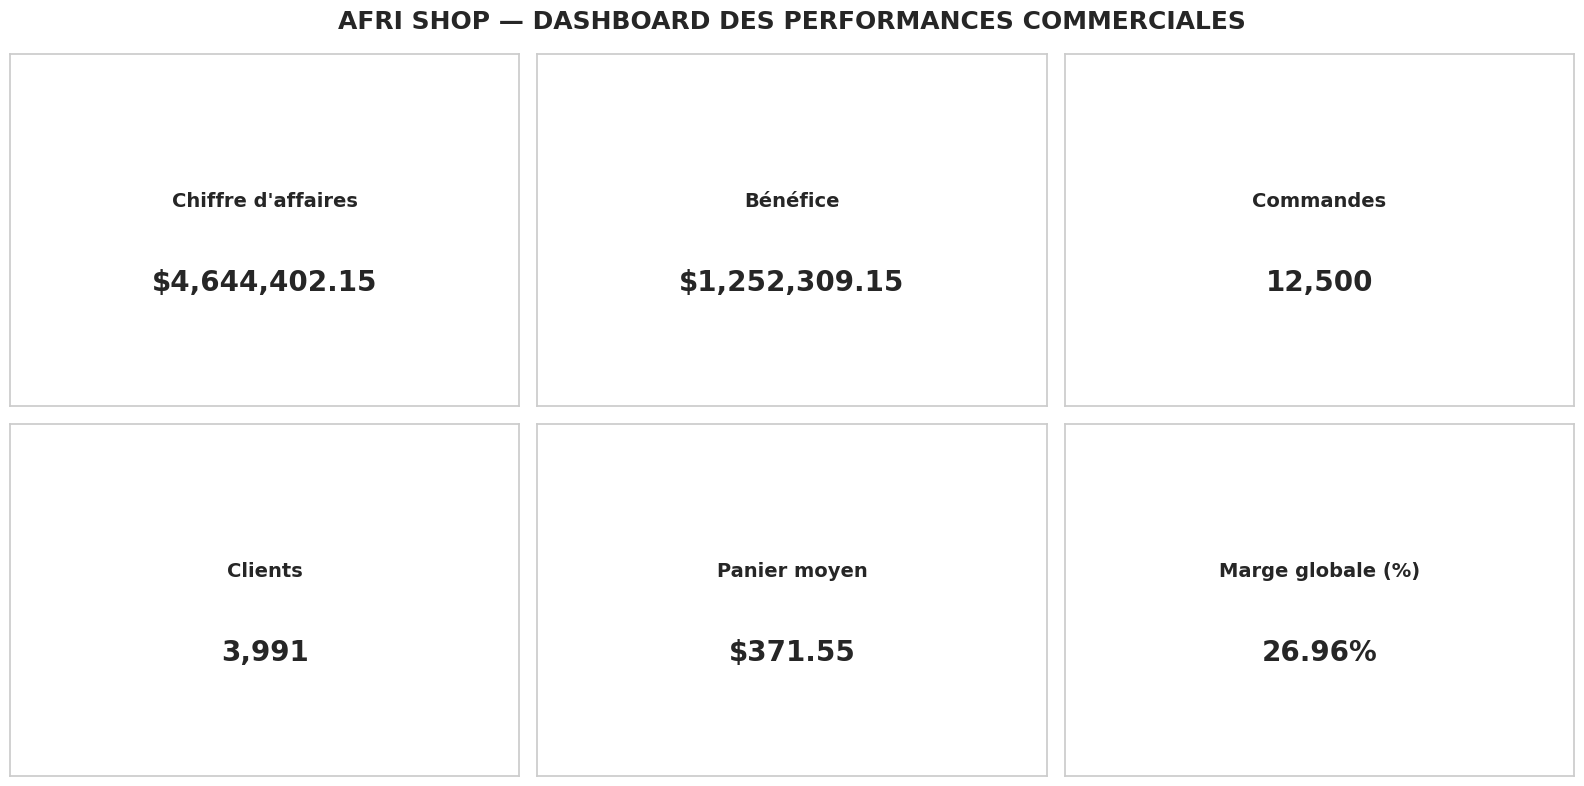

In [915]:
# ============================================================
# DASHBOARD KPI - AFRI SHOP
# ============================================================

import matplotlib.pyplot as plt

# Création des KPI
kpis = {
    "Chiffre d'affaires": total_revenue,
    "Bénéfice": total_profit,
    "Commandes": total_orders,
    "Clients": total_customers,
    "Panier moyen": average_order_value,
    "Marge globale (%)": global_margin
}

# Création du dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, value) in zip(axes, kpis.items()):

    ax.text(
        0.5,
        0.58,
        name,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

    if "%" in name:
        display_value = f"{value:.2f}%"
    elif name in ["Commandes", "Clients"]:
        display_value = f"{value:,}"
    else:
        display_value = f"${value:,.2f}"

    ax.text(
        0.5,
        0.35,
        display_value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)

fig.suptitle(
    "AFRI SHOP — DASHBOARD DES PERFORMANCES COMMERCIALES",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [916]:
# ============================================================
# ANALYSE TEMPORELLE - AFRI SHOP
# ============================================================

# Conversion de la date
df_analysis["order_date"] = pd.to_datetime(
    df_analysis["order_date"],
    errors="coerce"
)

# Création du mois
df_analysis["month"] = df_analysis["order_date"].dt.to_period("M")

# Agrégation mensuelle
monthly_performance = (
    df_analysis
    .groupby("month")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

# Conversion en date pour les graphiques
monthly_performance["month"] = (
    monthly_performance["month"].dt.to_timestamp()
)

# Affichage
print("========== PERFORMANCE MENSUELLE ==========\n")

display(monthly_performance)

========== PERFORMANCE MENSUELLE ==========



,month,revenue,profit,orders
0,2025-01-01,270583.38,72650.38,745
1,2025-02-01,237231.36,64528.36,640
2,2025-03-01,277204.74,74431.74,714
3,2025-04-01,239814.79,64421.79,642
4,2025-05-01,296884.15,78821.15,740
5,2025-06-01,260922.54,67718.54,649
6,2025-07-01,241069.86,65334.86,665
7,2025-08-01,262564.24,69962.24,680
8,2025-09-01,257717.20,68928.20,701
9,2025-10-01,255943.12,69492.12,706


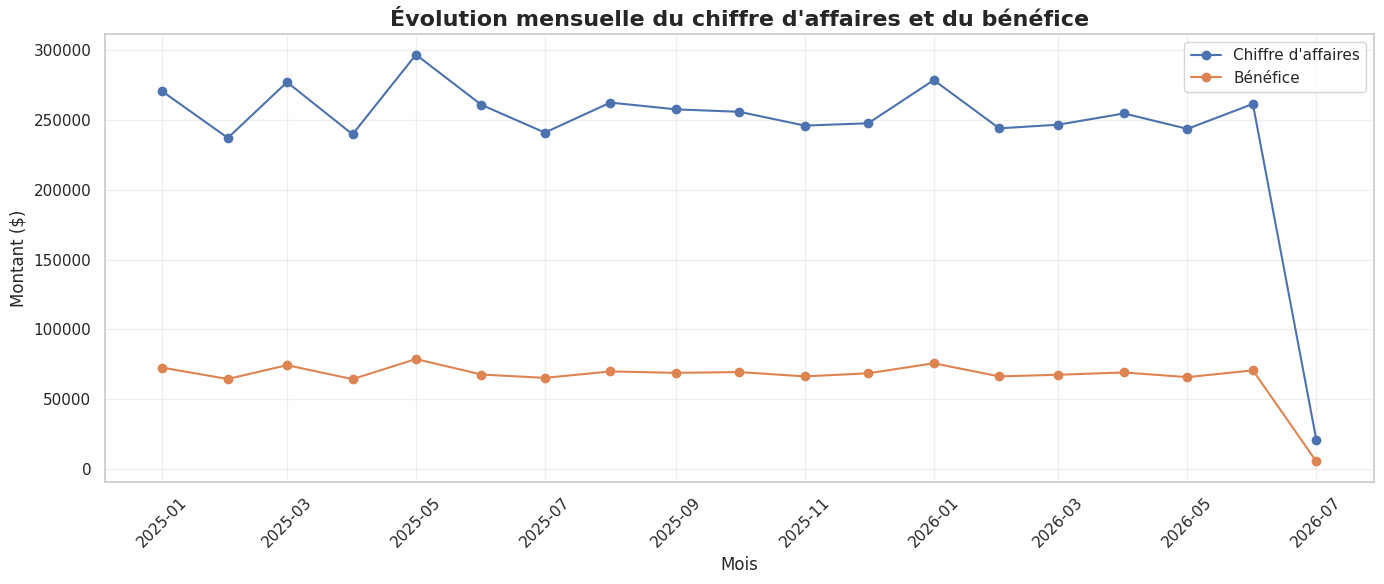

In [917]:
# ============================================================
# GRAPHIQUE - ÉVOLUTION CA ET BÉNÉFICE
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance["month"],
    monthly_performance["revenue"],
    marker="o",
    label="Chiffre d'affaires"
)

plt.plot(
    monthly_performance["month"],
    monthly_performance["profit"],
    marker="o",
    label="Bénéfice"
)

plt.title(
    "Évolution mensuelle du chiffre d'affaires et du bénéfice",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mois")
plt.ylabel("Montant ($)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [918]:
# ============================================================
# TOP PRODUITS - AFRI SHOP
# ============================================================

product_performance = (
    df_analysis
    .groupby(["product_name", "category"])
    .agg(
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

# Calcul de la marge
product_performance["margin_pct"] = (
    product_performance["profit"] /
    product_performance["revenue"] * 100
)

# Classement par chiffre d'affaires
top_products_revenue = (
    product_performance
    .sort_values("revenue", ascending=False)
    .head(10)
)

print("========== TOP 10 PRODUITS PAR CHIFFRE D'AFFAIRES ==========\n")

display(top_products_revenue)

========== TOP 10 PRODUITS PAR CHIFFRE D'AFFAIRES ==========



,product_name,category,quantity_sold,revenue,profit,margin_pct
15,Ordinateur portable HP 15,Ordinateurs,820,475305.90,102205.90,21.503184
16,Ordinateur portable Lenovo IdeaPad,Ordinateurs,869,431886.00,92976.00,21.527903
20,Smartphone Xiaomi Redmi,Smartphones,2090,379196.30,88686.30,23.387966
19,Smartphone Samsung Galaxy A,Smartphones,1455,339650.85,74840.85,22.034642
12,MacBook Air,Ordinateurs,300,338553.80,77553.80,22.907378
6,Dell Inspiron 15,Ordinateurs,485,333295.20,73820.20,22.148594
26,iPhone 15,Smartphones,388,331142.30,63422.30,19.152582
24,Tablette Samsung Galaxy Tab,Tablettes,868,239821.30,53201.30,22.183726
29,Écran Samsung 24 pouces,Écrans,1279,201798.30,58550.30,29.014268
28,Écran LG 27 pouces,Écrans,850,199501.05,55851.05,27.995366


In [919]:
# ============================================================
# PRODUITS À FORTE MARGE
# ============================================================

high_margin_products = (
    product_performance[
        product_performance["quantity_sold"] >= 100
    ]
    .sort_values("margin_pct", ascending=False)
    .head(10)
)

print("========== PRODUITS À FORTE MARGE ==========\n")

display(high_margin_products)

========== PRODUITS À FORTE MARGE ==========



,product_name,category,quantity_sold,revenue,profit,margin_pct
5,Clé USB 64 Go,Stockage,3074,35165.64,16721.64,47.551075
22,Support ordinateur,Accessoires,1759,45254.43,20628.43,45.583228
3,Clavier Logitech K120,Accessoires,2424,50875.00,21787.00,42.824570
27,Écouteurs sans fil,Audio,2658,96142.28,40324.28,41.942296
21,Souris Logitech M185,Accessoires,2754,47293.56,19753.56,41.767970
0,Adaptateur USB-C Hub,Accessoires,1623,52638.46,21801.46,41.417359
10,Enceinte Bluetooth portable,Audio,1430,74920.45,30590.45,40.830574
17,Power Bank 20 000 mAh,Énergie,1740,57938.65,23138.65,39.936467
2,Casque Bluetooth JBL,Audio,1874,128589.84,49881.84,38.791432
4,Clavier mécanique RGB,Accessoires,1109,68735.55,26593.55,38.689659


In [920]:
# ============================================================
# 📦 PERFORMANCE PAR CATÉGORIE
# ============================================================

category_performance = (
    df_analysis
    .groupby("category")
    .agg(
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

# Taux de marge
category_performance["margin_pct"] = (
    category_performance["profit"] /
    category_performance["revenue"] * 100
)

# Part du CA
category_performance["revenue_share_pct"] = (
    category_performance["revenue"] /
    category_performance["revenue"].sum() * 100
)

# Part du bénéfice
category_performance["profit_share_pct"] = (
    category_performance["profit"] /
    category_performance["profit"].sum() * 100
)

# Classement par CA
category_performance = category_performance.sort_values(
    "revenue",
    ascending=False
)

print("========== PERFORMANCE PAR CATÉGORIE ==========\n")

display(category_performance)

========== PERFORMANCE PAR CATÉGORIE ==========



,category,quantity_sold,revenue,profit,orders,margin_pct,revenue_share_pct,profit_share_pct
4,Ordinateurs,2474,1579040.90,346555.90,1205,21.947240,33.998798,27.673350
6,Smartphones,3933,1049989.45,226949.45,1878,21.614451,22.607634,18.122478
9,Écrans,2129,401299.35,114401.35,1038,28.507734,8.640495,9.135232
1,Audio,6621,351314.21,140167.21,3059,39.897962,7.564250,11.192700
0,Accessoires,10994,325113.80,133780.80,4849,41.148915,7.000122,10.682730
7,Stockage,6792,284762.16,104032.16,3082,36.533000,6.131299,8.307227
8,Tablettes,868,239821.30,53201.30,441,22.183726,5.163664,4.248256
10,Énergie,2700,129513.79,48633.79,1272,37.551052,2.788600,3.883529
3,Imprimantes,719,127150.50,28647.50,371,22.530387,2.737715,2.287574
5,Réseau,2574,105473.79,39387.79,1250,37.343676,2.270987,3.145213


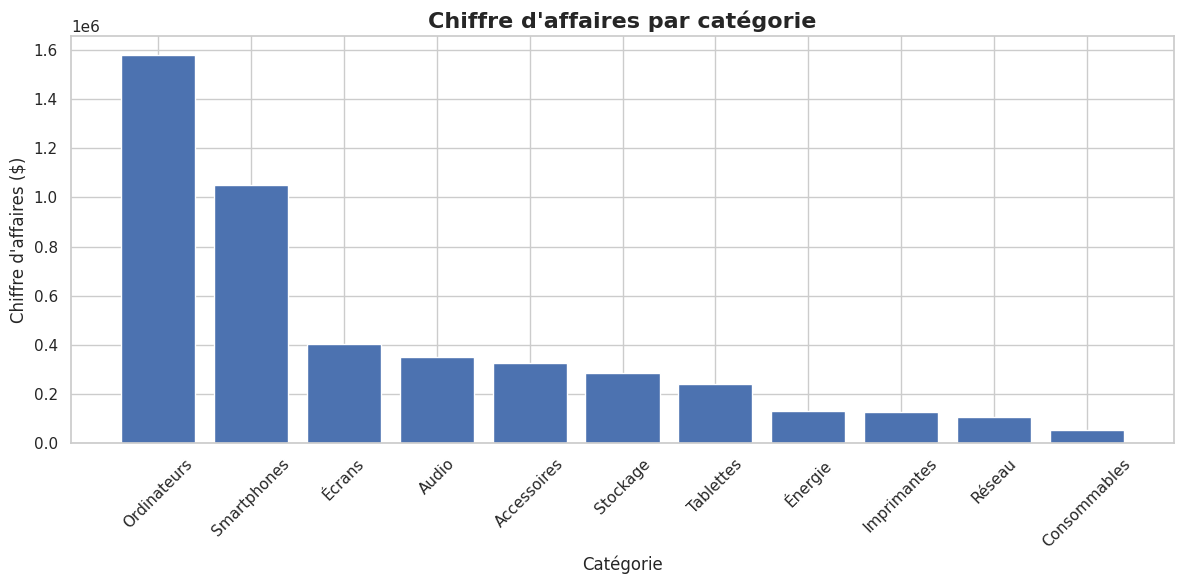

In [921]:
# ============================================================
# GRAPHIQUE — CA PAR CATÉGORIE
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    category_performance["category"],
    category_performance["revenue"]
)

plt.title(
    "Chiffre d'affaires par catégorie",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaires ($)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

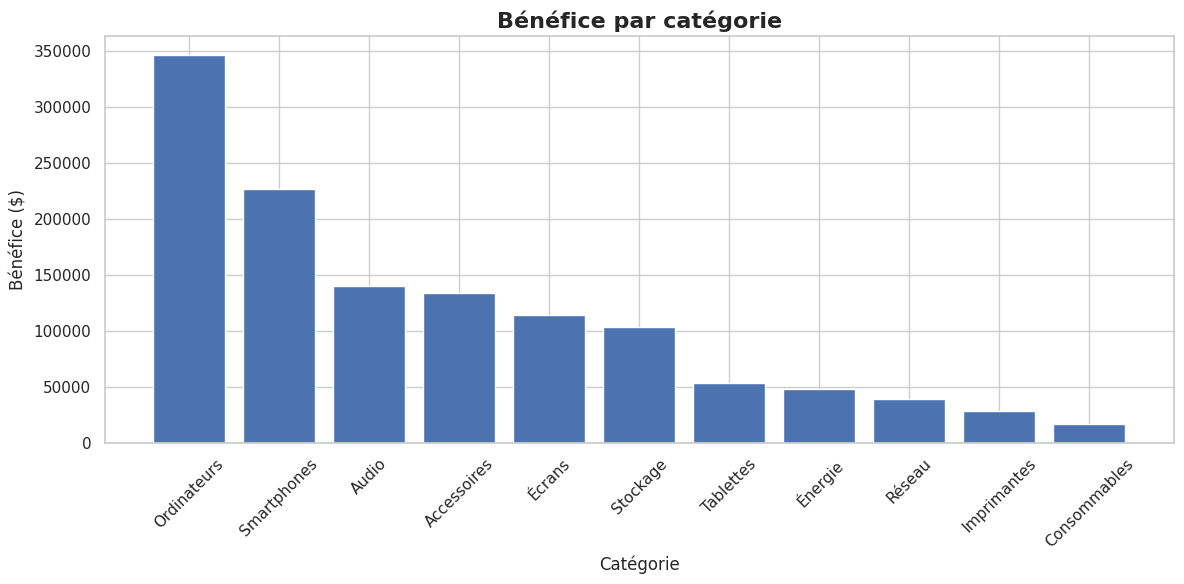

In [922]:
# ============================================================
# GRAPHIQUE — BÉNÉFICE PAR CATÉGORIE
# ============================================================

category_profit_sorted = category_performance.sort_values(
    "profit",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    category_profit_sorted["category"],
    category_profit_sorted["profit"]
)

plt.title(
    "Bénéfice par catégorie",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Catégorie")
plt.ylabel("Bénéfice ($)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [923]:
# ============================================================
# INSIGHTS CATÉGORIES
# ============================================================

best_category_revenue = category_performance.loc[
    category_performance["revenue"].idxmax()
]

best_category_profit = category_performance.loc[
    category_performance["profit"].idxmax()
]

best_category_margin = category_performance.loc[
    category_performance["margin_pct"].idxmax()
]

print("========== INSIGHTS CATÉGORIES ==========\n")

print(
    f"🏆 Plus gros CA : "
    f"{best_category_revenue['category']} "
    f"(${best_category_revenue['revenue']:,.2f})"
)

print(
    f"💰 Plus gros bénéfice : "
    f"{best_category_profit['category']} "
    f"(${best_category_profit['profit']:,.2f})"
)

print(
    f"📈 Meilleure marge : "
    f"{best_category_margin['category']} "
    f"({best_category_margin['margin_pct']:.2f}%)"
)


========== INSIGHTS CATÉGORIES ==========

🏆 Plus gros CA : Ordinateurs ($1,579,040.90)
💰 Plus gros bénéfice : Ordinateurs ($346,555.90)
📈 Meilleure marge : Accessoires (41.15%)


Insight : Les ordinateurs constituent le principal moteur de revenus et de bénéfices d'AFRI SHOP, tandis que les accessoires présentent la meilleure rentabilité relative avec une marge de 41,15 %. L'entreprise pourrait donc continuer à développer les ordinateurs pour leur contribution financière et renforcer la vente d'accessoires à forte marge, notamment grâce à des stratégies de ventes croisées.


In [924]:
customer_analysis = (
    df_analysis
    .groupby(["customer_id", "first_name", "last_name", "country", "segment"])
    .agg(
        orders=("order_id", "nunique"),
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

customer_analysis["margin_pct"] = (
    customer_analysis["profit"] /
    customer_analysis["revenue"] * 100
)

customer_analysis = customer_analysis.sort_values(
    "revenue",
    ascending=False
)

customer_analysis.head(10)

,customer_id,first_name,last_name,country,segment,orders,quantity_sold,revenue,profit,margin_pct
2056,C02158,Koffi,Sow,Côte d'Ivoire,Particulier,5,16,8410.53,1874.53,22.287894
1215,C01281,Rodrigue,Adjovi,Côte d'Ivoire,Particulier,6,33,8116.66,1954.66,24.082073
1420,C01494,Aminata,Ndiaye,Togo,Particulier,8,34,8067.80,2124.80,26.336796
22,C00026,Moussa,Baba,Côte d'Ivoire,Particulier,6,27,7879.83,2162.83,27.447673
243,C00260,Franck,Kouassi,Sénégal,Particulier,6,25,7872.23,1923.23,24.430562
453,C00479,Junior,Kaboré,Togo,Particulier,4,18,7359.30,1761.30,23.932983
3419,C03601,Ruth,Traoré,Ghana,PME,9,31,7221.17,1668.17,23.101104
980,C01035,Fabrice,Adjovi,Togo,Particulier,6,28,7179.16,1798.16,25.046941
2634,C02772,Oumar,Sow,Sénégal,Particulier,5,33,7063.98,1851.98,26.217232
917,C00970,Natacha,Ndiaye,Bénin,Particulier,10,38,6894.95,1511.95,21.928368


In [925]:
top_customer_revenue = customer_analysis.iloc[0]

top_customer_profit = customer_analysis.loc[
    customer_analysis["profit"].idxmax()
]

top_customer_margin = customer_analysis.loc[
    customer_analysis["margin_pct"].idxmax()
]

print("🏆 Plus gros CA client :")
print(
    top_customer_revenue[
        ["customer_id", "first_name", "last_name", "revenue"]
    ]
)

print("\n💰 Client avec le plus gros bénéfice :")
print(
    top_customer_profit[
        ["customer_id", "first_name", "last_name", "profit"]
    ]
)

print("\n📈 Client avec la meilleure marge :")
print(
    top_customer_margin[
        ["customer_id", "first_name", "last_name", "margin_pct"]
    ]
)

🏆 Plus gros CA client :
customer_id     C02158
first_name       Koffi
last_name          Sow
revenue        8410.53
Name: 2056, dtype: object

💰 Client avec le plus gros bénéfice :
customer_id     C00026
first_name      Moussa
last_name         Baba
profit         2162.83
Name: 22, dtype: object

📈 Client avec la meilleure marge :
customer_id       C00397
first_name         David
last_name      Ahouansou
margin_pct          50.0
Name: 376, dtype: object


Les clients les plus importants ne sont pas nécessairement les mêmes selon le critère utilisé. Koffi Sow domine en chiffre d'affaires, Moussa Baba en bénéfice et David Ahouansou en marge. AFRI SHOP doit donc segmenter ses clients selon leur valeur économique, plutôt que de se baser uniquement sur le montant dépensé.

In [926]:
top_clients_orders = (
    customer_analysis
    .sort_values("orders", ascending=False)
    .head(10)
)

top_clients_orders[
    ["customer_id", "first_name", "last_name", "orders", "revenue", "profit"]
]

,customer_id,first_name,last_name,orders,revenue,profit
1696,C01779,David,Kaboré,12,4840.35,1365.35
3947,C04164,Chantal,Zinsou,10,5329.04,1007.04
2236,C02352,Yannick,Dossou,10,3050.29,782.29
930,C00983,Samuel,Amoussou,10,2151.90,672.90
917,C00970,Natacha,Ndiaye,10,6894.95,1511.95
1904,C01999,Chantal,Tchibozo,10,4438.00,1099.00
688,C00725,David,Amani,9,2870.45,884.45
1796,C01882,Ismaël,Amoussou,9,1581.78,489.78
3473,C03658,Yannick,Kaboré,9,1839.50,500.50
122,C00134,Ibrahim,Ndiaye,9,1658.00,528.00


Les clients les plus fidèles ne sont pas nécessairement les plus rentables. David Kaboré possède le plus grand nombre de commandes (12), tandis que Natacha Ndiaye génère un chiffre d'affaires et un bénéfice supérieurs avec 10 commandes. AFRI SHOP devrait donc analyser conjointement la fréquence d'achat et la valeur générée afin d'identifier ses clients à plus forte valeur.

In [927]:
customer_analysis["customer_value"] = pd.qcut(
    customer_analysis["revenue"],
    q=3,
    labels=["Faible", "Moyenne", "Élevée"]
)

customer_segments = (
    customer_analysis
    .groupby("customer_value", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        orders=("orders", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

customer_segments["margin_pct"] = (
    customer_segments["profit"] /
    customer_segments["revenue"] * 100
)

customer_segments

,customer_value,customers,orders,revenue,profit,margin_pct
0,Faible,1328,2611,303063.38,107845.38,35.585091
1,Moyenne,1327,4250,1093962.91,323330.91,29.555930
2,Élevée,1328,5616,3240621.50,819384.50,25.284795


AFRI SHOP devrait prioriser la fidélisation des clients à forte valeur en développant des offres personnalisées et des stratégies de rétention, tout en analysant les remises, les produits achetés et les coûts associés à ces clients afin d'améliorer leur marge.

/tmp/ipykernel_1503/2800303676.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_analysis, x="sales_channel_x", y="revenue", palette="Blues_r", ax=ax_channel)
/tmp/ipykernel_1503/2800303676.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_analysis, x="country", y="revenue", palette="viridis", ax=ax_country)
/tmp/ipykernel_1503/2800303676.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cats, y="category", x="revenue", palette="rocket", ax=ax_category)
/usr/local/lib/python3.13/dist-packages/IPyth

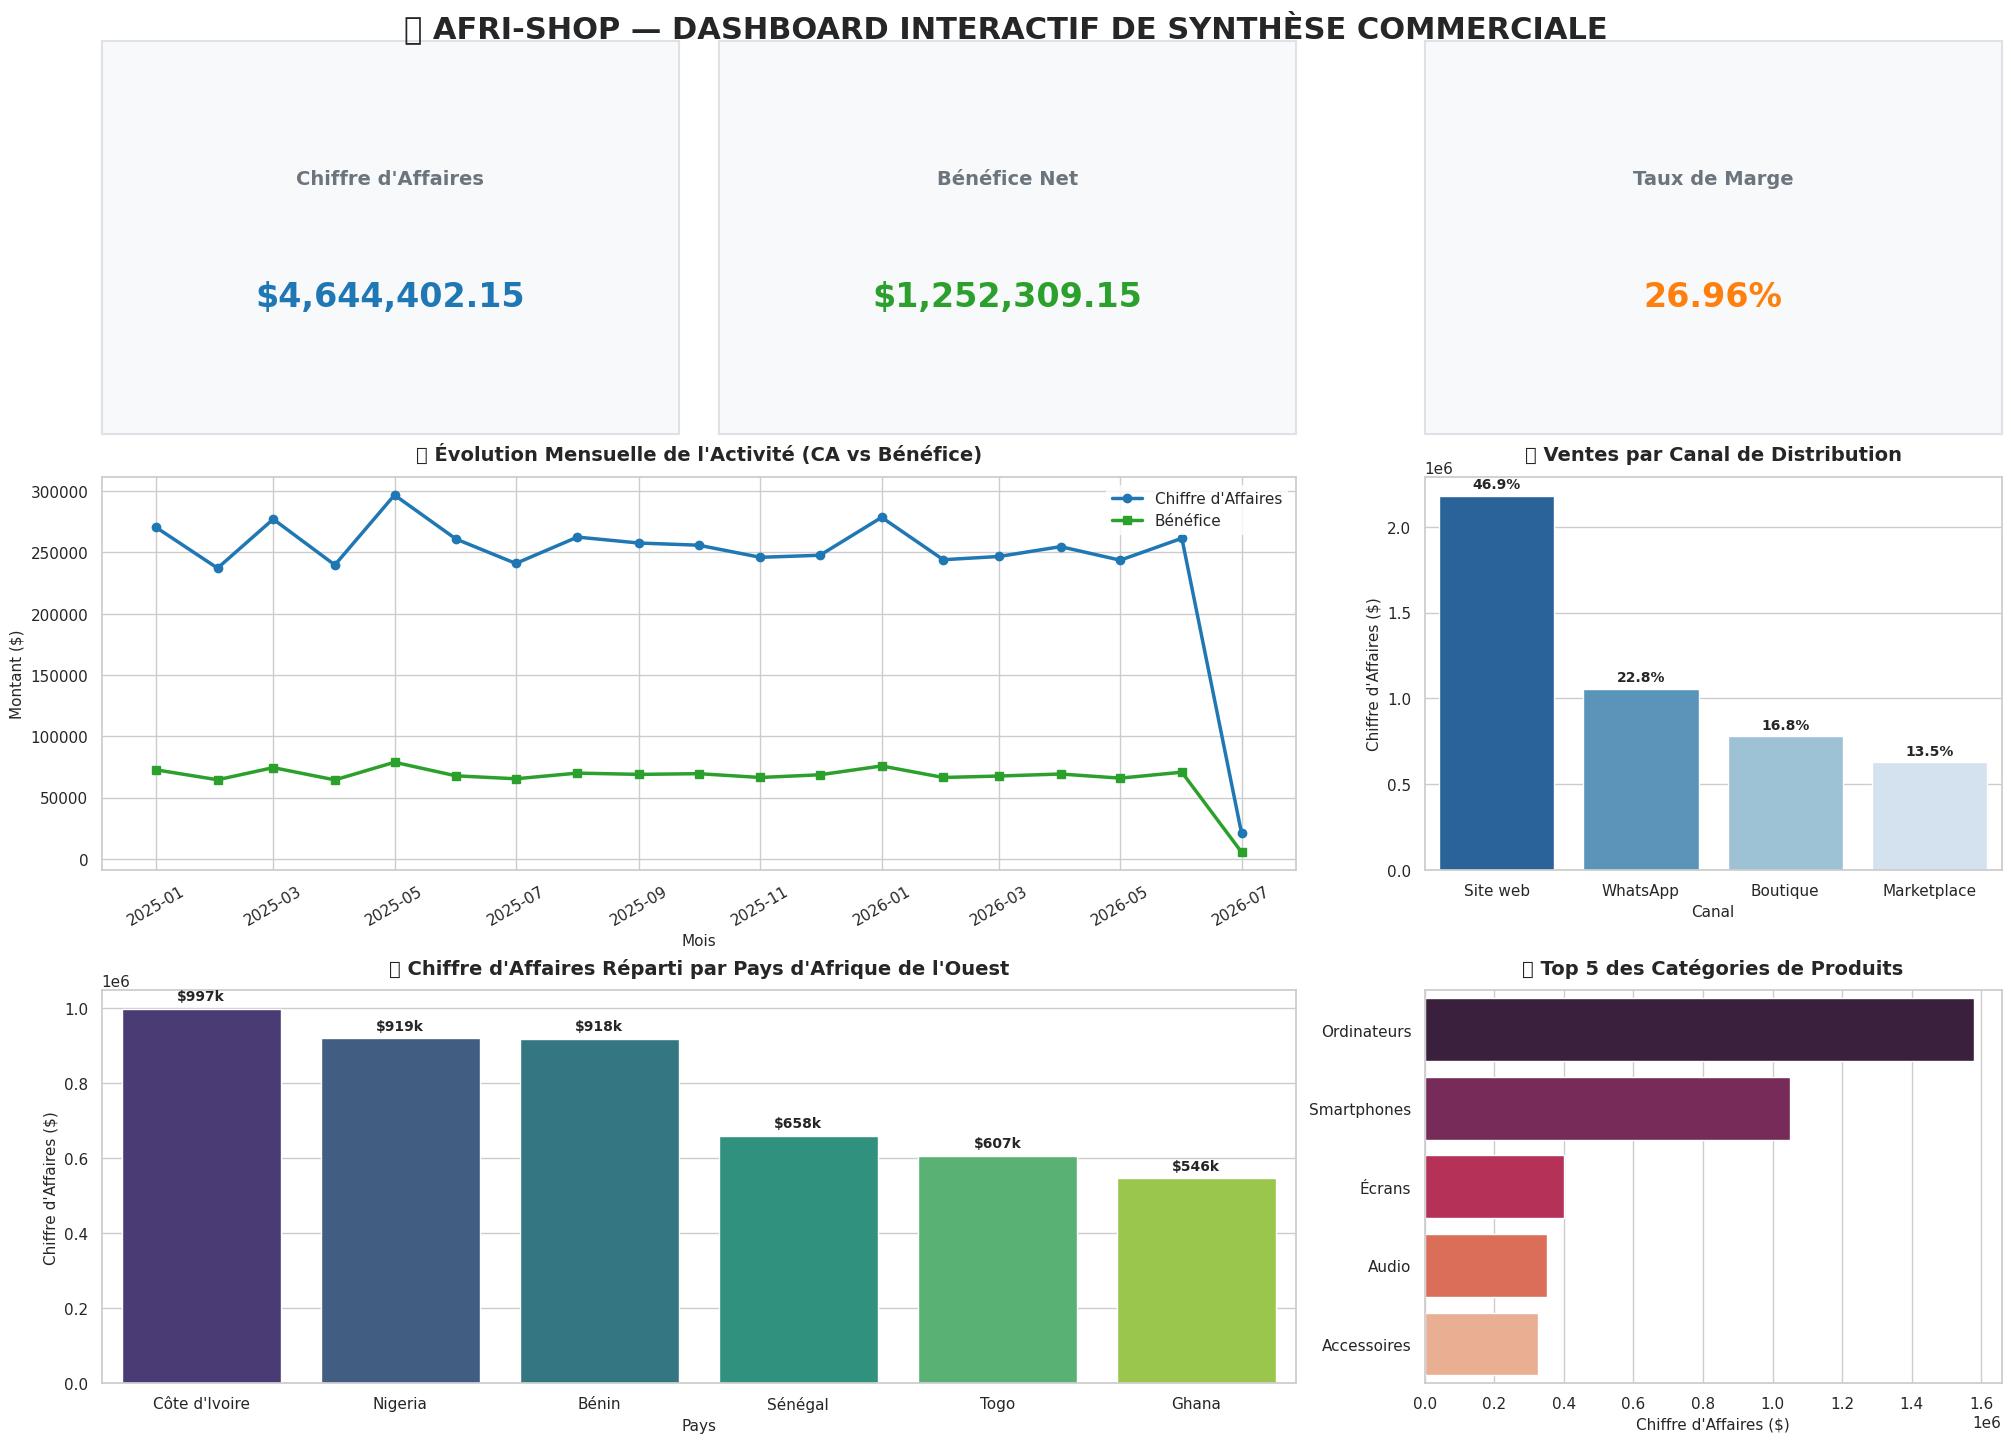

In [928]:

# Configuration du style
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# Initialisation de la figure multi-onglets (GridSpec)
fig = plt.figure(figsize=(20, 14), constrained_layout=True)
gs = fig.add_gridspec(3, 3)

# ==========================================
# SECTION 1 : CARTES DE KPI (LIGNE DU HAUT)
# ==========================================
kpis_to_plot = [
    ("Chiffre d'Affaires", f"${total_revenue:,.2f}", "#1f77b4"),
    ("Bénéfice Net", f"${total_profit:,.2f}", "#2ca02c"),
    ("Taux de Marge", f"{global_margin:.2f}%", "#ff7f0e")
]

for col_idx, (title, value, color) in enumerate(kpis_to_plot):
    ax_kpi = fig.add_subplot(gs[0, col_idx])
    ax_kpi.set_facecolor("#f8f9fa")
    # Masquer les axes
    ax_kpi.xaxis.set_visible(False)
    ax_kpi.yaxis.set_visible(False)
    for spine in ax_kpi.spines.values():
        spine.set_color("#dee2e6")
        spine.set_linewidth(1.5)

    # Textes du KPI
    ax_kpi.text(0.5, 0.65, title, ha="center", va="center", fontsize=14, color="#6c757d", fontweight="bold")
    ax_kpi.text(0.5, 0.35, value, ha="center", va="center", fontsize=24, color=color, fontweight="bold")

# ==========================================
# SECTION 2 : ÉVOLUTION TEMPORELLE (LIGNE 2, LARGEUR 2 BLOCS)
# ==========================================
ax_temp = fig.add_subplot(gs[1, :2])
ax_temp.plot(monthly_performance["month"], monthly_performance["revenue"], marker="o", linewidth=2.5, color="#1f77b4", label="Chiffre d'Affaires")
ax_temp.plot(monthly_performance["month"], monthly_performance["profit"], marker="s", linewidth=2.5, color="#2ca02c", label="Bénéfice")
ax_temp.set_title("📈 Évolution Mensuelle de l'Activité (CA vs Bénéfice)", fontsize=14, fontweight="bold", pad=12)
ax_temp.set_xlabel("Mois", fontsize=11)
ax_temp.set_ylabel("Montant ($)", fontsize=11)
ax_temp.legend(frameon=True, facecolor="#ffffff", edgecolor="none")
ax_temp.tick_params(axis='x', rotation=30)

# ==========================================
# SECTION 3 : RÉPARTITION PAR CANAL DE VENTE (LIGNE 2, DROITE)
# ==========================================
ax_channel = fig.add_subplot(gs[1, 2])
sns.barplot(data=channel_analysis, x="sales_channel_x", y="revenue", palette="Blues_r", ax=ax_channel)
ax_channel.set_title("🛒 Ventes par Canal de Distribution", fontsize=14, fontweight="bold", pad=12)
ax_channel.set_xlabel("Canal", fontsize=11)
ax_channel.set_ylabel("Chiffre d'Affaires ($)", fontsize=11)
# Ajout des étiquettes de pourcentage de contribution
for i, bar in enumerate(ax_channel.patches):
    percentage = channel_analysis.iloc[i]["revenue_share_pct"]
    ax_channel.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 25000, f"{percentage:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ==========================================
# SECTION 4 : CLASSEMENT DES PAYS (LIGNE 3, LARGEUR 2 BLOCS)
# ==========================================
ax_country = fig.add_subplot(gs[2, :2])
sns.barplot(data=country_analysis, x="country", y="revenue", palette="viridis", ax=ax_country)
ax_country.set_title("🌍 Chiffre d'Affaires Réparti par Pays d'Afrique de l'Ouest", fontsize=14, fontweight="bold", pad=12)
ax_country.set_xlabel("Pays", fontsize=11)
ax_country.set_ylabel("Chiffre d'Affaires ($)", fontsize=11)
# Ajout des montants au-dessus des barres
for bar in ax_country.patches:
    height = bar.get_height()
    ax_country.text(bar.get_x() + bar.get_width()/2, height + 15000, f"${height/1000:,.0f}k", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ==========================================
# SECTION 5 : TOP CATÉGORIES (LIGNE 3, DROITE)
# ==========================================
ax_category = fig.add_subplot(gs[2, 2])
top_cats = category_performance.head(5)
sns.barplot(data=top_cats, y="category", x="revenue", palette="rocket", ax=ax_category)
ax_category.set_title("🏆 Top 5 des Catégories de Produits", fontsize=14, fontweight="bold", pad=12)
ax_category.set_xlabel("Chiffre d'Affaires ($)", fontsize=11)
ax_category.set_ylabel("", fontsize=11)

# Titre Global du Dashboard
fig.suptitle("🎯 AFRI-SHOP — DASHBOARD INTERACTIF DE SYNTHÈSE COMMERCIALE", fontsize=22, fontweight="bold", y=1.02)

plt.show()

```markdown
## 📝 Conclusion et Recommandations Stratégiques Finales

En croisant l'ensemble de ces visualisations et de nos analyses, voici la feuille de route business recommandée pour **AFRI-SHOP** :

1. **Amplification de la présence en Côte d'Ivoire & Bénén/Nigeria** :
   - Ces trois pays représentent près de **60% du chiffre d'affaires global**. La Côte d'Ivoire est à elle seule le leader incontesté (CA proche du million de dollars).
   - *Action* : Augmenter les budgets marketing ciblés sur Abidjan, Cotonou et Lagos.

2. **Exploitation du potentiel de marge au Togo** :
   - Bien qu'ayant des volumes inférieurs, le **Togo affiche la meilleure rentabilité relative (marge de 27.11%)**.
   - *Action* : Introduire des gammes d'accessoires complémentaires sur ce territoire pour tirer profit de cette rentabilité naturelle.

3. **Optimisation du Canal Web et WhatsApp** :
   - Le **Site Web** porte l'essentiel de notre réussite (**46.9% du CA**), suivi de près par **WhatsApp (22.8%)**.
   - *Action* : Automatiser les prises de commandes sur WhatsApp (via des chatbots ou des catalogues intégrés) pour réduire le temps de traitement opérationnel et augmenter le panier moyen.

4. **Stratégie de Cross-Selling Équipements ↔ Accessoires** :
   - Les **Ordinateurs** et **Smartphones** génèrent les plus gros volumes de ventes, mais les **Accessoires** détiennent la marge la plus forte (**41.15%**).
   - *Action* : Proposer systématiquement des suggestions d'achats d'accessoires (Clés USB, supports, chargeurs) lors de l'ajout au panier d'un ordinateur ou d'un téléphone sur le site web.
```